# MMDocRAG

## 1. Setup

In [1]:
import json
import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
import yaml
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import NullFormatter

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
B = "mmdocrag"
DIR = ROOT / "data" / B
RAW = DIR / "raw"

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

In [2]:
# Plot style. Categorical slots 1–3 of the reference palette; blue = pure-text, orange = multimodal.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#8a8984", "#fcfcfb", "#e6e5e1"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#2a78d6", "#1c5cab", "#0d366b"])
MODE_COLOR = {"pure-text": BLUE, "multimodal": ORANGE}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.axisbelow": True, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.frameon": False, "legend.fontsize": 8.5,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]), "lines.linewidth": 2,
    "figure.dpi": 110,
})

In [3]:
# Helpers

def parse_json(s):
    return json.loads(s) if isinstance(s, str) and s.strip() else None


def short(x, n=60):
    x = str(x).replace("\n", " ⏎ ")
    return x if len(x) <= n else x[: n - 1] + "…"


def panels(n, width=5.2, height=3.4):
    fig, axes = plt.subplots(1, n, figsize=(width * n, height), squeeze=False)
    return fig, axes[0]


def show(fig):
    fig.tight_layout()
    plt.show()


def hist(ax, values, title, xlabel, bins=40, logx=False, color=BLUE):
    values = pd.Series(values).dropna()
    if logx:
        values = values[values > 0]
        bins = np.logspace(np.log10(values.min()), np.log10(values.max()), bins)
        ax.set_xscale("log")
    ax.hist(values, bins=bins, color=color, edgecolor=SURFACE, linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")
    ax.grid(axis="x", visible=False)


def barh(ax, counts, title, xlabel="count", top=20, color=BLUE):
    counts = counts.head(top)[::-1]
    ax.barh([short(i, 40) for i in counts.index], counts.values, color=color, height=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)


def binned_mean(ax, x, y, title, xlabel, q=10, logx=False, clip=None, color=BLUE, label=None, ylabel="mean score"):
    """Mean of y within quantile bins of x (or per value of a discrete x clipped at `clip`), ±1.96·SE band."""
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    if clip is not None:
        d["x"] = d.x.clip(upper=clip)
        d["bin"] = d.x
    else:
        d["bin"] = pd.qcut(d.x.rank(method="first"), q, labels=False)
    g = d.groupby("bin").agg(x=("x", "median"), y=("y", "mean"), sd=("y", "std"), n=("y", "size"))
    g = g[g.n >= 30]
    se = g.sd / np.sqrt(g.n)
    ax.fill_between(g.x, g.y - 1.96 * se, g.y + 1.96 * se, color=color, alpha=0.18, linewidth=0)
    ax.plot(g.x, g.y, color=color, marker="o", markersize=5, label=label)
    if logx:
        ax.set_xscale("log")
        ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_title(title)
    ax.set_xlabel(xlabel + (f" (≥ {clip} pooled)" if clip is not None else ""))
    ax.set_ylabel(ylabel)


def spearman(a, b):
    return pd.Series(a).corr(pd.Series(b), method="spearman")

## 2. Metadata and provenance

### 2.1 `benchmarks.parquet`

In [4]:
bench = pd.read_parquet(DIR / "benchmarks.parquet").iloc[0]
print(textwrap.fill(bench.description, 120), "\n")
display(bench.drop("description").to_frame("value"))

MMDocRAG tests whether models can answer questions about documents by weaving retrieved text and images into a cited
answer, which a judge model rates for fluency, citation quality, coherence, reasoning and factuality. 



,value
benchmark_id,mmdocrag
name,MMDocRAG
version,NaN
license,CC-BY-NC-4.0
source_url,https://github.com/MMDocRAG/MMDocRAG
one_line_description,NaN
modality,"[image, text]"
domain,"[general, reasoning]"
multi_single_turn,single_turn
response_type,fraction


### 2.2 `metadata.yaml`, `characterization.yaml` and the build's source claims

In [5]:
meta = yaml.safe_load((DIR / "metadata.yaml").read_text())
char = yaml.safe_load((DIR / "characterization.yaml").read_text())
print("testing_condition:\n" + textwrap.fill(meta["benchmark"]["testing_condition"], 120), "\n")
print("upstream sources:")
for s in meta["sources"]["upstream"]:
    print(f"  {s['url']}  @ {s['revision']}")

rows = {t: pq.ParquetFile(DIR / f"{'response' if t == 'responses' else t}.parquet").metadata.num_rows
        for t in char["tables"]}
display(pd.DataFrame({
    "declared_rows": {t: v["rows"] for t, v in char["tables"].items()},
    "actual_rows": rows,
}).assign(match=lambda d: d.declared_rows == d.actual_rows))
display(pd.DataFrame({k: {"expected": v["expected"], "scope": short(v["scope"], 110)}
                      for k, v in char["source_claims"].items()}).T)

testing_condition:
test_condition is the run config "{mode}/quotes{N}": mode is "pure-text" (quotes as text input) or "multimodal" (quotes
as interleaved text+image for VLMs), and N (15 or 20) is the number of retrieved quotes given as context. Items are
individual questions (q_id); response is the per-item LLM-as-judge answer-quality score (mean of Fluency, Citation
Quality, Text-Image Coherence, Reasoning Logic, Factuality) normalized to [0, 1] (divided by 5). The judge is
gpt-4o-2024-08-06 for pure-text answers and the same model given the cited images for multimodal answers, prompted with
prompt_bank/evaluation_answer.txt; each dimension is graded 0-5, where 0 is "completely fails to meet the requirement"
and is the grade an empty or failed answer receives. Responses are left unobserved (None) for the 0.04% of rows whose
judge output did not yield all five dimensions. 

upstream sources:
  https://github.com/MMDocRAG/MMDocRAG  @ 2fd7505c6a576376b4a92aafaff6d87494765bb7


,declared_rows,actual_rows,match
benchmarks,1,1,True
items,2000,2000,True
responses,342695,342695,True
subjects,68,68,True
traces,328286,328286,True


,expected,scope
released_questions,2000,Union of released question IDs; repeated appearances count once.
released_judge_attempts,342695,"Retained judge attempts, including incomplete judge outputs stored as ungrad..."


In [6]:
# What the raw folder holds besides the harmonised tables.
for p in sorted(RAW.iterdir()):
    n = len(list(p.iterdir())) if p.is_dir() else None
    size = sum(f.stat().st_size for f in p.rglob("*")) if p.is_dir() else p.stat().st_size
    print(f"  {p.name:<22} {'dir, ' + str(n) + ' files' if n is not None else 'file':<18} {size / 1e6:8.1f} MB")

  eval                   dir, 173 files         56.1 MB
  evaluation_15.jsonl    file                   23.9 MB
  evaluation_20.jsonl    file                   31.6 MB
  reproducibility        dir, 2 files          252.3 MB
  resp                   dir, 191 files        765.8 MB


## 3. Subjects

In [7]:
subjects = pd.read_parquet(DIR / "subjects.parquet")
print(f"{len(subjects)} subjects · subject_id unique: {subjects.subject_id.is_unique} · display_name unique: "
      f"{subjects.display_name.is_unique} · normalized_name unique: {subjects.normalized_name.is_unique}")
print("columns entirely null:", [c for c in subjects if subjects[c].isna().all()])
print("providers:", subjects.provider.value_counts().to_dict())
display(subjects[["display_name", "normalized_name", "provider", "release_date", "subject_features_extra"]]
        .sort_values(["provider", "display_name"]).reset_index(drop=True))

68 subjects · subject_id unique: True · display_name unique: True · normalized_name unique: False
columns entirely null: ['access_date', 'harness', 'reasoning_effort', 'harness_version']
providers: {'Alibaba': 24, 'OpenGVLab': 9, 'OpenAI': 7, 'Google': 6, 'DeepSeek': 5, 'Meta': 5, 'Community': 5, 'Mistral': 3, 'xAI': 2, 'Anthropic': 1, 'OpenBMB': 1}


,display_name,normalized_name,provider,release_date,subject_features_extra
0,qvq-max-no-think,Alibaba QVQ-Max,Alibaba,2025-03-28,released_variant=no-think
1,qwen-max,Alibaba Qwen Max,Alibaba,2023-11-10,NaN
2,qwen-plus,Alibaba Qwen Plus,Alibaba,2023-09,NaN
3,qwen-qvq-max,Alibaba QVQ-Max,Alibaba,2025-03-28,NaN
4,qwen-qwq-plus,Alibaba QwQ Plus,Alibaba,2025-03-05,NaN
...,...,...,...,...,...
63,internvl3-78b,OpenGVLab InternVL3 78B,OpenGVLab,2025-04-11,NaN
64,internvl3-8B,OpenGVLab InternVL3 8B,OpenGVLab,2025-04-11,NaN
65,internvl3-9B,OpenGVLab InternVL3 9B,OpenGVLab,2025-04-11,NaN
66,grok-3-beta,xAI Grok 3,xAI,2025-02-17,NaN


In [8]:
# normalized_name is shared by model variants that behave differently (thinking on/off).
coll = subjects[subjects.normalized_name.duplicated(keep=False)].sort_values("normalized_name")
display(coll[["display_name", "normalized_name", "subject_features_extra"]].reset_index(drop=True))

# Release dates that are not a full day, and names whose normalisation changes the model.
partial = subjects[subjects.release_date.str.len() != 10]
print("release_date not YYYY-MM-DD:", partial[["display_name", "release_date"]].values.tolist())
print("fine-tuned by the MMDocRAG authors (provider 'Community'):",
      subjects.loc[subjects.provider == "Community", "display_name"].tolist())

,display_name,normalized_name,subject_features_extra
0,qvq-max-no-think,Alibaba QVQ-Max,released_variant=no-think
1,qwen-qvq-max,Alibaba QVQ-Max,NaN
2,qwen3-14b-no-think,Alibaba Qwen3 14B,released_variant=no-think
3,qwen3-14b,Alibaba Qwen3 14B,NaN
4,qwen3-30b-a3b-no-think,Alibaba Qwen3 30B A3B,released_variant=no-think
5,qwen3-30b-a3b,Alibaba Qwen3 30B A3B,NaN
6,qwen3-8b-no-think,Alibaba Qwen3 8B,released_variant=no-think
7,qwen3-8b,Alibaba Qwen3 8B,NaN


release_date not YYYY-MM-DD: [['qwen-plus', '2023-09']]
fine-tuned by the MMDocRAG authors (provider 'Community'): ['qwen2.5-14b-ft', 'qwen2.5-32b-ft', 'qwen2.5-3b-ft', 'qwen2.5-72b-ft', 'qwen2.5-7b-ft']


## 4. Items

### 4.1 Structure and integrity

In [9]:
items = pd.read_parquet(DIR / "items.parquet")
print(f"{len(items):,} items · item_id unique: {items.item_id.is_unique} · raw_item_id unique: "
      f"{items.raw_item_id.is_unique} · content_hash unique: {items.content_hash.is_unique}")
print("columns entirely null:", [c for c in items if items[c].isna().all()])

crit = items.grading_criterion.map(parse_json)
ver = items.verifier.map(parse_json)
print("grading_criterion keys:", sorted({k for d in crit for k in d}), "· distinct rules:", crit.map(lambda d: d["rule"]).nunique())
print("verifier:", ver.map(lambda v: (v["class"], v.get("judged_by"))).value_counts().to_dict(),
      "· distinct specs:", ver.map(lambda v: v["spec"]).nunique())
print("rule:", textwrap.fill(crit.iloc[0]["rule"], 120))

items = items.assign(
    q_id=items.raw_item_id.str.removeprefix("q_id::").astype(int),
    reference=crit.map(lambda d: d["reference_answer"]),
)
print(f"\ncontent = the question only; median {items.content.str.len().median():.0f} characters "
      f"(max {items.content.str.len().max()})")
display(items[["raw_item_id", "content", "reference"]].head(3))

2,000 items · item_id unique: True · raw_item_id unique: True · content_hash unique: True
columns entirely null: ['asset_manifest', 'item_features']


grading_criterion keys: ['reference_answer', 'rule'] · distinct rules: 1
verifier: {('judge', 'llm'): 2000} · distinct specs: 1
rule: Mean of the five 0-5 scores for Fluency, Citation Quality, Text-Image Coherence, Reasoning Logic, and Factuality,
divided by 5. A missing or invalid dimension leaves the grade unavailable.



content = the question only; median 112 characters (max 361)


,raw_item_id,content,reference
0,q_id::1,"Among the Higher-income seniors, what are the percentage of them go online, ...","['90%', '42%', '39%']"
1,q_id::2,How many types of ecosystem players are listed in the slide?,20
2,q_id::3,What percentage of the party that holds the highest total percentage of good...,21%


### 4.2 The retrieved context lives only in the raw question files

In [10]:
ev = {n: pd.read_json(RAW / f"evaluation_{n}.jsonl", lines=True).set_index("q_id").sort_index() for n in (15, 20)}
print("raw question fields:", ev[15].columns.tolist())
e15, e20 = ev[15].loc[items.q_id], ev[20].loc[items.q_id]
print("q_id::N ↔ raw q_id N — question matches:", (items.content.values == e15.question.values).mean(),
      "· reference == answer_short:", (items.reference.values == e15.answer_short.values).mean())
print("15- and 20-quote files share question, answer, document and labels:",
      all((ev[15][c] == ev[20][c]).all() for c in ["question", "answer_short", "doc_name", "domain", "question_type"]))

def quote_ids(row):
    return {q["quote_id"] for q in row.text_quotes + row.img_quotes}

for n, e in [(15, e15), (20, e20)]:
    nt, ni = e.text_quotes.map(len), e.img_quotes.map(len)
    gold_in = [set(g) <= quote_ids(r) for g, r in zip(e.gold_quotes, e.itertuples())]
    print(f"quotes{n}: text quotes {nt.value_counts().idxmax()} (mode), image quotes {ni.value_counts().idxmax()} (mode), "
          f"total {(nt + ni).value_counts().idxmax()} · all gold quotes among the candidates: {np.mean(gold_in):.3f}")
print("number of gold quotes equal in both files:", (e15.gold_quotes.map(len).values == e20.gold_quotes.map(len).values).mean())

raw question fields: ['doc_name', 'domain', 'question', 'evidence_modality_type', 'question_type', 'text_quotes', 'img_quotes', 'gold_quotes', 'answer_short', 'answer_interleaved', 'old_id']
q_id::N ↔ raw q_id N — question matches: 1.0 · reference == answer_short: 1.0
15- and 20-quote files share question, answer, document and labels: True
quotes15: text quotes 10 (mode), image quotes 5 (mode), total 15 · all gold quotes among the candidates: 1.000
quotes20: text quotes 12 (mode), image quotes 8 (mode), total 20 · all gold quotes among the candidates: 1.000
number of gold quotes equal in both files: 1.0


In [11]:
# One question rendered as the model sees it in pure-text mode (images replaced by their descriptions).
row = e15.iloc[0]
print("Q:", row.question, "\nA:", row.answer_short, "· gold quotes:", row.gold_quotes, "\n")
for q in row.text_quotes[:2]:
    print(f"[{q['quote_id']}] (text, page {q['page_id']})", textwrap.shorten(q["text"], 220))
for q in row.img_quotes[:2]:
    print(f"[{q['quote_id']}] (image {q['img_path']})", textwrap.shorten(q["img_description"], 220))

Q: Among the Higher-income seniors, what are the percentage of them go online, has smartphone phone, and own a tablet computer? Please write the answer in the list format and in descend order,e.g., ["9%","8%"] in the Pew Research Center’s Internet Project July 18-September 30, 2013 tracking survey? 
A: ['90%', '42%', '39%'] · gold quotes: ['text3', 'image5', 'image3', 'text5', 'image4'] 

[text1] (text, page 7) Fully $77\%$ of seniors are now cell phone owners. This trails the national average— ${\bf\cdot91\%}$ of all Americans own a cell phone—but represents a significant year-to-year increase over the $69\%$ of seniors [...]
[text2] (text, page 7)  College graduates — $\cdot87\%$ of seniors with a college degree go online, and $76\%$ are broadband adopters.
[image1] (image images/PIP_Seniors-and-Tech-Use_040314_image5.jpg) This image shows a line graph depicting trends over time from 2000 to 2013. It compares two groups: "All Adults 18+" and "65+". - The darker line represents "All 

### 4.3 Item characteristics

,count,mean,std,min,5%,25%,50%,75%,95%,max
q_chars,2000.0,118.6,44.3,16.0,59.0,85.0,112.0,147.0,199.0,361.0
answer_chars,2000.0,127.0,92.8,1.0,2.0,58.0,117.0,193.0,286.0,540.0
n_gold,2000.0,2.9,1.8,1.0,1.0,1.0,2.0,4.0,6.0,12.0
n_gold_img,2000.0,1.6,0.9,0.0,1.0,1.0,1.0,2.0,3.0,8.0
n_gold_text,2000.0,1.3,1.4,0.0,0.0,0.0,1.0,2.0,4.0,10.0
n_evidence_types,2000.0,1.7,0.6,1.0,1.0,1.0,2.0,2.0,3.0,4.0
ctx_chars_15,2000.0,8510.3,3249.5,838.0,3612.7,5795.0,8431.0,10917.0,13717.7,23584.0
ctx_chars_20,2000.0,11672.8,4182.2,1739.0,5167.0,8401.5,11622.0,14942.5,18241.2,32870.0


evidence needs (share of items): {'text': np.float64(0.621), 'table': np.float64(0.521), 'chart': np.float64(0.242), 'figure': np.float64(0.322), 'layout': np.float64(0.004)}
items whose gold evidence includes an image quote: 99.8% · only images: 37.9%


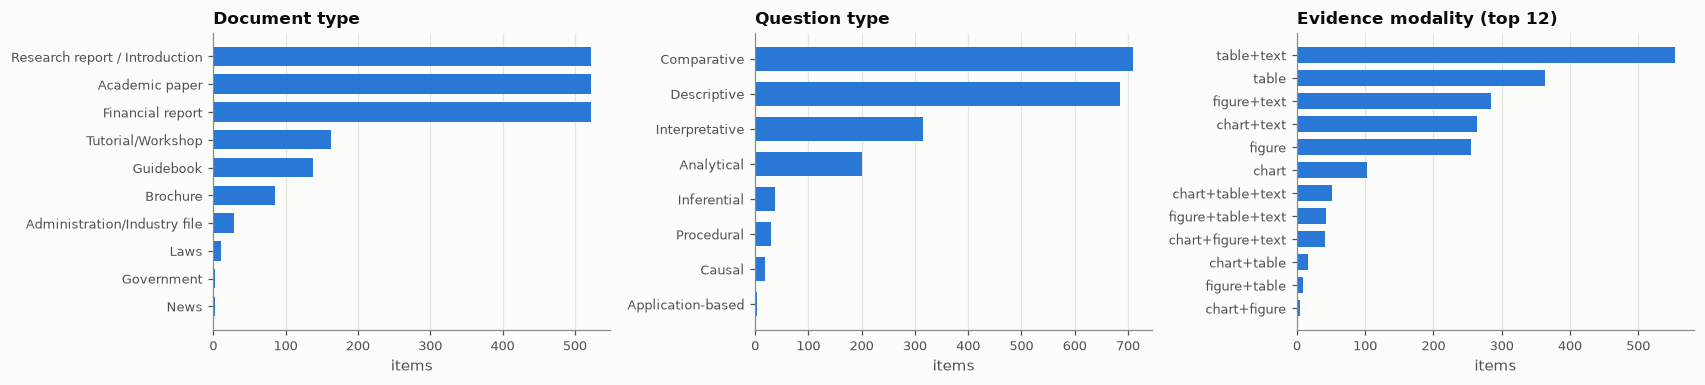

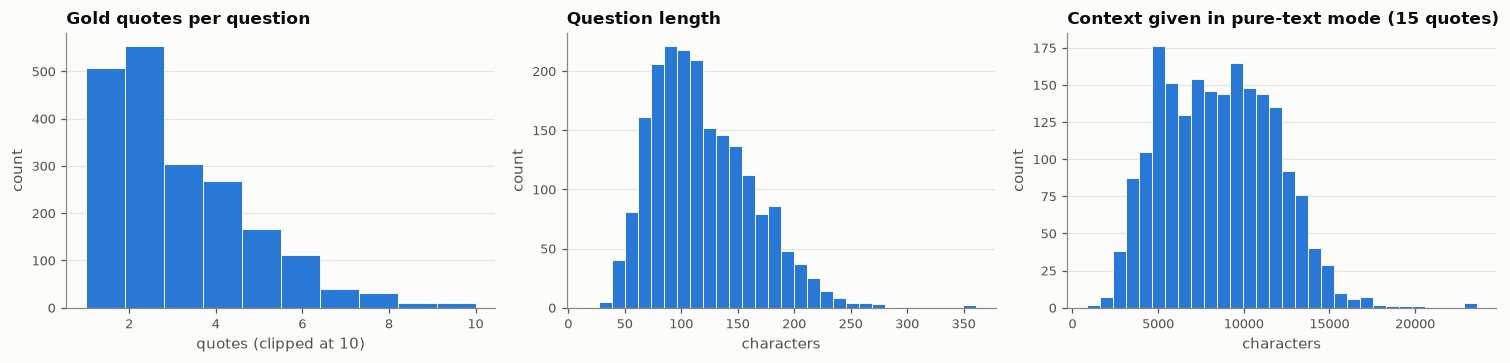

In [12]:
def context_chars(row):
    return sum(len(q["text"]) for q in row.text_quotes) + sum(len(q["img_description"] or "") for q in row.img_quotes)


def has(mods, m):
    return m in mods


iv = pd.DataFrame({
    "item_id": items.item_id.values,
    "q_id": items.q_id.values,
    "doc_name": e15.doc_name.values,
    "doc_type": e15.domain.values,
    "question_type": e15.question_type.values,
    "evidence": e15.evidence_modality_type.map(lambda m: "+".join(sorted(m))).values,
    "n_evidence_types": e15.evidence_modality_type.map(len).values,
    "n_gold": e15.gold_quotes.map(len).values,
    "n_gold_img": e15.gold_quotes.map(lambda g: sum(x.startswith("image") for x in g)).values,
    "q_chars": items.content.str.len().values,
    "answer_chars": e15.answer_short.str.len().values,
    "ctx_chars_15": [context_chars(r) for r in e15.itertuples()],
    "ctx_chars_20": [context_chars(r) for r in e20.itertuples()],
}).set_index("item_id")
for m in ["text", "table", "chart", "figure", "layout"]:
    iv[f"ev_{m}"] = e15.evidence_modality_type.map(lambda x, m=m: m in x).values
iv["n_gold_text"] = iv.n_gold - iv.n_gold_img

NUM = ["q_chars", "answer_chars", "n_gold", "n_gold_img", "n_gold_text", "n_evidence_types", "ctx_chars_15", "ctx_chars_20"]
display(iv[NUM].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.round(1))
print("evidence needs (share of items):", {m: round(iv[f"ev_{m}"].mean(), 3) for m in ["text", "table", "chart", "figure", "layout"]})
print(f"items whose gold evidence includes an image quote: {(iv.n_gold_img > 0).mean():.1%} · only images: "
      f"{(iv.n_gold_text == 0).mean():.1%}")

fig, axes = panels(3, width=5.2, height=3.6)
barh(axes[0], iv.doc_type.value_counts(), "Document type", "items")
barh(axes[1], iv.question_type.value_counts(), "Question type", "items")
barh(axes[2], iv.evidence.value_counts(), "Evidence modality (top 12)", "items", top=12)
show(fig)

fig, axes = panels(3, width=4.6)
hist(axes[0], iv.n_gold.clip(upper=10), "Gold quotes per question", "quotes (clipped at 10)", bins=10)
hist(axes[1], iv.q_chars, "Question length", "characters", bins=30)
hist(axes[2], iv.ctx_chars_15, "Context given in pure-text mode (15 quotes)", "characters", bins=30)
show(fig)

### 4.4 Documents

In [13]:
per_doc = iv.groupby("doc_name").agg(questions=("q_id", "size"), doc_type=("doc_type", "first"))
print(f"{len(per_doc)} documents · questions per document: median {per_doc.questions.median():.0f}, "
      f"max {per_doc.questions.max()} · single-question documents: {(per_doc.questions == 1).sum()}")
print("each document has one doc_type:", iv.groupby("doc_name").doc_type.nunique().eq(1).all())
display(per_doc.groupby("doc_type").agg(documents=("questions", "size"), questions=("questions", "sum"))
        .sort_values("questions", ascending=False))

220 documents · questions per document: median 8, max 27 · single-question documents: 13
each document has one doc_type: True


,documents,questions
doc_type,,
Academic paper,72,523
Research report / Introduction,33,523
Financial report,51,522
Tutorial/Workshop,17,163
Guidebook,21,138
Brochure,14,86
Administration/Industry file,4,29
Laws,6,11
Government,1,3


### 4.5 Images

In [14]:
img_paths = {q["img_path"] for e in (ev[15], ev[20]) for qs in e.img_quotes for q in qs}
local = {p.name for p in DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
present = sum(Path(p).name in local for p in img_paths)
print(f"distinct image quotes referenced: {len(img_paths):,} · image files under data/{B}: {len(local)} · "
      f"referenced images available locally: {present}")
desc = pd.Series([len(q["img_description"] or "") for qs in ev[15].img_quotes for q in qs])
print(f"image descriptions: median {desc.median():.0f} characters, empty {(desc == 0).sum()}")

distinct image quotes referenced: 5,056 · image files under data/mmdocrag: 0 · referenced images available locally: 0
image descriptions: median 755 characters, empty 0


## 5. Responses: scores, conditions and coverage

### 5.1 Structure

In [15]:
resp = pd.read_parquet(DIR / "response.parquet")
print(f"{len(resp):,} responses · response_id unique: {resp.response_id.is_unique} · trials: {sorted(resp.trial.unique())} · "
      f"interactors all null: {resp.interactors.isna().all()}")
print(f"missing scores: {resp.response.isna().sum()} ({resp.response.isna().mean():.2%}) · distinct values: "
      f"{resp.response.nunique()} · range [{resp.response.min()}, {resp.response.max()}]")
print("duplicate (subject, item, condition):", resp.duplicated(["subject_id", "item_id", "test_condition"]).sum(),
      "· orphan items:", (~resp.item_id.isin(items.item_id)).sum(), "· orphan subjects:", (~resp.subject_id.isin(subjects.subject_id)).sum())

resp = resp.merge(subjects[["subject_id", "display_name"]], on="subject_id").merge(items[["item_id", "q_id"]], on="item_id")
resp[["mode", "quotes"]] = resp.test_condition.str.extract(r"(pure-text|multimodal)/quotes(\d+)")
resp["quotes"] = resp.quotes.astype(int)
display(resp.groupby("test_condition").agg(rows=("response", "size"), subjects=("subject_id", "nunique"),
                                           items=("item_id", "nunique"), mean_score=("response", "mean")).round(3))

342,695 responses · response_id unique: True · trials: [np.int64(1)] · interactors all null: True
missing scores: 129 (0.04%) · distinct values: 26 · range [0.0, 1.0]
duplicate (subject, item, condition): 0 · orphan items: 0 · orphan subjects: 0


,rows,subjects,items,mean_score
test_condition,,,,
multimodal/quotes15,61966,31,2000,0.635
multimodal/quotes20,63963,32,2000,0.622
pure-text/quotes15,108458,55,2000,0.693
pure-text/quotes20,108308,55,2000,0.689


In [16]:
cov = resp.pivot_table(index="display_name", columns="test_condition", values="item_id", aggfunc="size")
runs_mm = cov[["multimodal/quotes15", "multimodal/quotes20"]].notna().any(axis=1)
print(f"subjects run in multimodal mode: {runs_mm.sum()} · pure-text only: {(~runs_mm).sum()} · "
      f"multimodal only: {cov[['pure-text/quotes15', 'pure-text/quotes20']].isna().all(axis=1).sum()}")
print("subjects run on all four conditions:", cov.notna().all(axis=1).sum())
incomplete = cov[(cov < 2000).any(axis=1) & cov.notna().any(axis=1)]
print("cells with fewer than 2,000 items:")
display(incomplete.where(incomplete < 2000).dropna(how="all", axis=1).dropna(how="all").fillna("").astype(str))

subjects run in multimodal mode: 32 · pure-text only: 36 · multimodal only: 13
subjects run on all four conditions: 19
cells with fewer than 2,000 items:


test_condition,multimodal/quotes15,multimodal/quotes20,pure-text/quotes15,pure-text/quotes20
display_name,,,,
deepseek-r1-distill-llama-70b,,,1999.0,1999.0
deepseek-r1-distill-qwen-32b,,,1999.0,1999.0
gemini-1.5-pro,,,1981.0,1986.0
gemini-2.0-flash,,,1984.0,1979.0
gemini-2.0-pro,,1999.0,,
gemini-2.5-flash,1971.0,1970.0,,
gemini-2.5-pro,,,,1999.0
gpt-4.1,,,1999.0,
gpt-4.1-mini,,,,1999.0


### 5.2 Score distribution

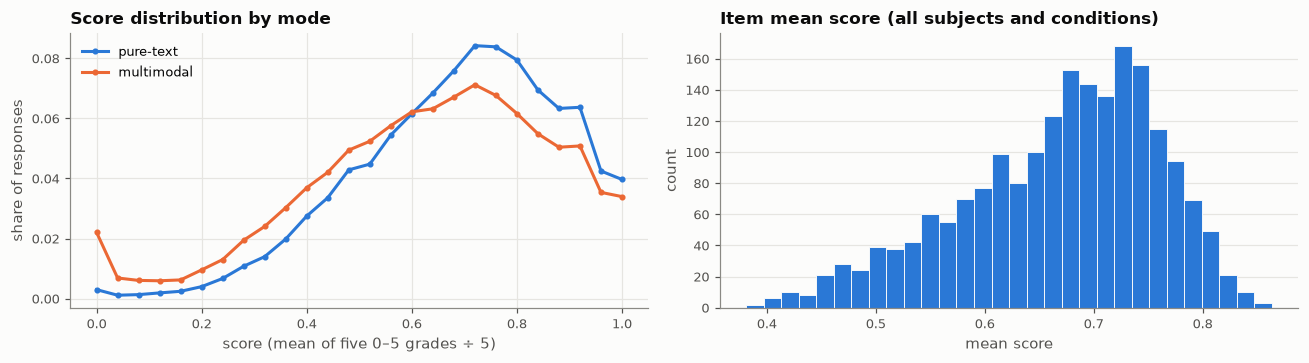

score quantiles: {'5%': 0.28, '25%': 0.52, '50%': 0.68, '75%': 0.84, '95%': 0.96} · exact 0: 1.00% · exact 1: 3.75%


In [17]:
fig, axes = panels(2, width=6)
vals = np.round(np.arange(0, 1.0001, 0.04), 2)
for mode, colour in MODE_COLOR.items():
    s = resp.loc[resp["mode"] == mode, "response"].dropna().round(2).value_counts(normalize=True).reindex(vals, fill_value=0)
    axes[0].plot(s.index, s.values, color=colour, marker="o", markersize=3, label=mode)
axes[0].set_title("Score distribution by mode")
axes[0].set_xlabel("score (mean of five 0–5 grades ÷ 5)")
axes[0].set_ylabel("share of responses")
axes[0].legend()
item_mean = resp.groupby("item_id").response.mean()
hist(axes[1], item_mean, "Item mean score (all subjects and conditions)", "mean score", bins=30)
show(fig)
q = resp.response.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print("score quantiles:", q[["5%", "25%", "50%", "75%", "95%"]].round(2).to_dict(), f"· exact 0: {(resp.response == 0).mean():.2%} · "
      f"exact 1: {(resp.response == 1).mean():.2%}")

### 5.3 Effect of the condition, paired within subject and item

In [18]:
wide = resp.pivot_table(index=["subject_id", "item_id"], columns="test_condition", values="response")
pairs = {
    "multimodal − pure-text (15 quotes)": ("multimodal/quotes15", "pure-text/quotes15"),
    "multimodal − pure-text (20 quotes)": ("multimodal/quotes20", "pure-text/quotes20"),
    "20 − 15 quotes (pure-text)": ("pure-text/quotes20", "pure-text/quotes15"),
    "20 − 15 quotes (multimodal)": ("multimodal/quotes20", "multimodal/quotes15"),
}
rows = {}
for name, (a, b) in pairs.items():
    d = (wide[a] - wide[b]).dropna()
    rows[name] = {"pairs": len(d), "subjects": d.index.get_level_values(0).nunique(), "mean diff": d.mean(),
                  "share higher": (d > 0).mean(), "share equal": (d == 0).mean(), "share lower": (d < 0).mean(),
                  "corr(a, b)": wide[[a, b]].dropna().corr().iloc[0, 1]}
display(pd.DataFrame(rows).T.round(3))

,pairs,subjects,mean diff,share higher,share equal,share lower,"corr(a, b)"
multimodal − pure-text (15 quotes),37892.0,19.0,-0.009,0.431,0.094,0.475,0.396
multimodal − pure-text (20 quotes),37889.0,19.0,-0.011,0.427,0.095,0.478,0.423
20 − 15 quotes (pure-text),108195.0,55.0,-0.004,0.440,0.107,0.453,0.576
20 − 15 quotes (multimodal),61890.0,31.0,-0.013,0.418,0.104,0.478,0.665


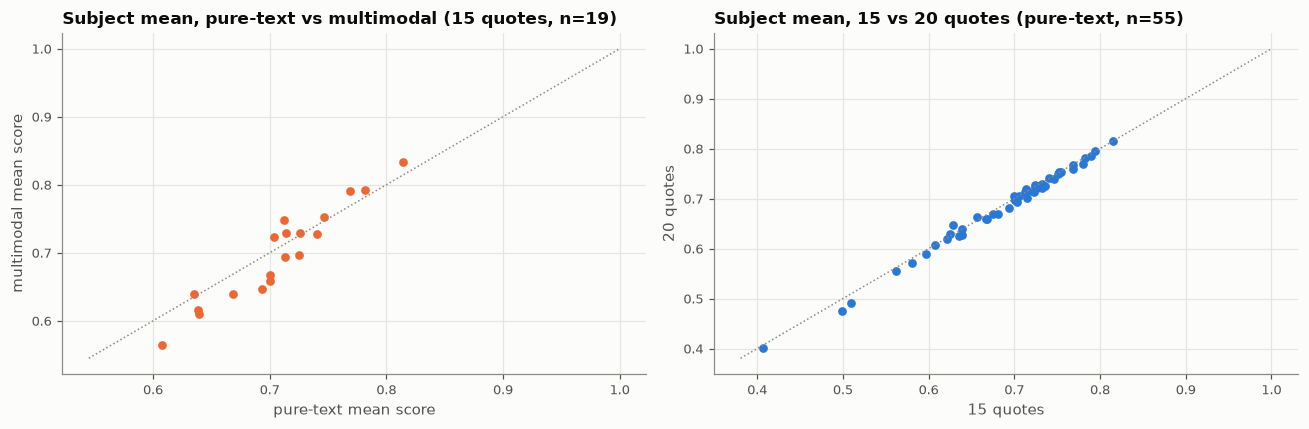

Spearman of subject means across conditions:


test_condition,multimodal/quotes15,multimodal/quotes20,pure-text/quotes15,pure-text/quotes20
test_condition,,,,
multimodal/quotes15,1.000,0.993,0.944,0.919
multimodal/quotes20,0.993,1.000,0.921,0.898
pure-text/quotes15,0.944,0.921,1.000,0.991
pure-text/quotes20,0.919,0.898,0.991,1.000


In [19]:
# Per subject: mean in pure-text vs multimodal (quotes15), for subjects run in both.
sm = resp.pivot_table(index="display_name", columns="test_condition", values="response", aggfunc="mean")
both = sm.dropna(subset=["pure-text/quotes15", "multimodal/quotes15"])
fig, axes = panels(2, width=6, height=4)
ax = axes[0]
ax.scatter(both["pure-text/quotes15"], both["multimodal/quotes15"], color=ORANGE, s=22)
lim = [both[["pure-text/quotes15", "multimodal/quotes15"]].min().min() - 0.02, 1]
ax.plot(lim, lim, color=MUTED, linewidth=1, linestyle=":")
for name, r in both.iterrows():
    if abs(r["multimodal/quotes15"] - r["pure-text/quotes15"]) > 0.06:
        ax.annotate(name, (r["pure-text/quotes15"], r["multimodal/quotes15"]), fontsize=7, color=INK2,
                    xytext=(3, 3), textcoords="offset points")
ax.set_title(f"Subject mean, pure-text vs multimodal (15 quotes, n={len(both)})")
ax.set_xlabel("pure-text mean score")
ax.set_ylabel("multimodal mean score")
ax = axes[1]
both20 = sm.dropna(subset=["pure-text/quotes15", "pure-text/quotes20"])
ax.scatter(both20["pure-text/quotes15"], both20["pure-text/quotes20"], color=BLUE, s=22)
lim = [both20[["pure-text/quotes15", "pure-text/quotes20"]].min().min() - 0.02, 1]
ax.plot(lim, lim, color=MUTED, linewidth=1, linestyle=":")
ax.set_title(f"Subject mean, 15 vs 20 quotes (pure-text, n={len(both20)})")
ax.set_xlabel("15 quotes")
ax.set_ylabel("20 quotes")
show(fig)
print("Spearman of subject means across conditions:")
display(sm.corr(method="spearman").round(3))

### 5.4 Subjects

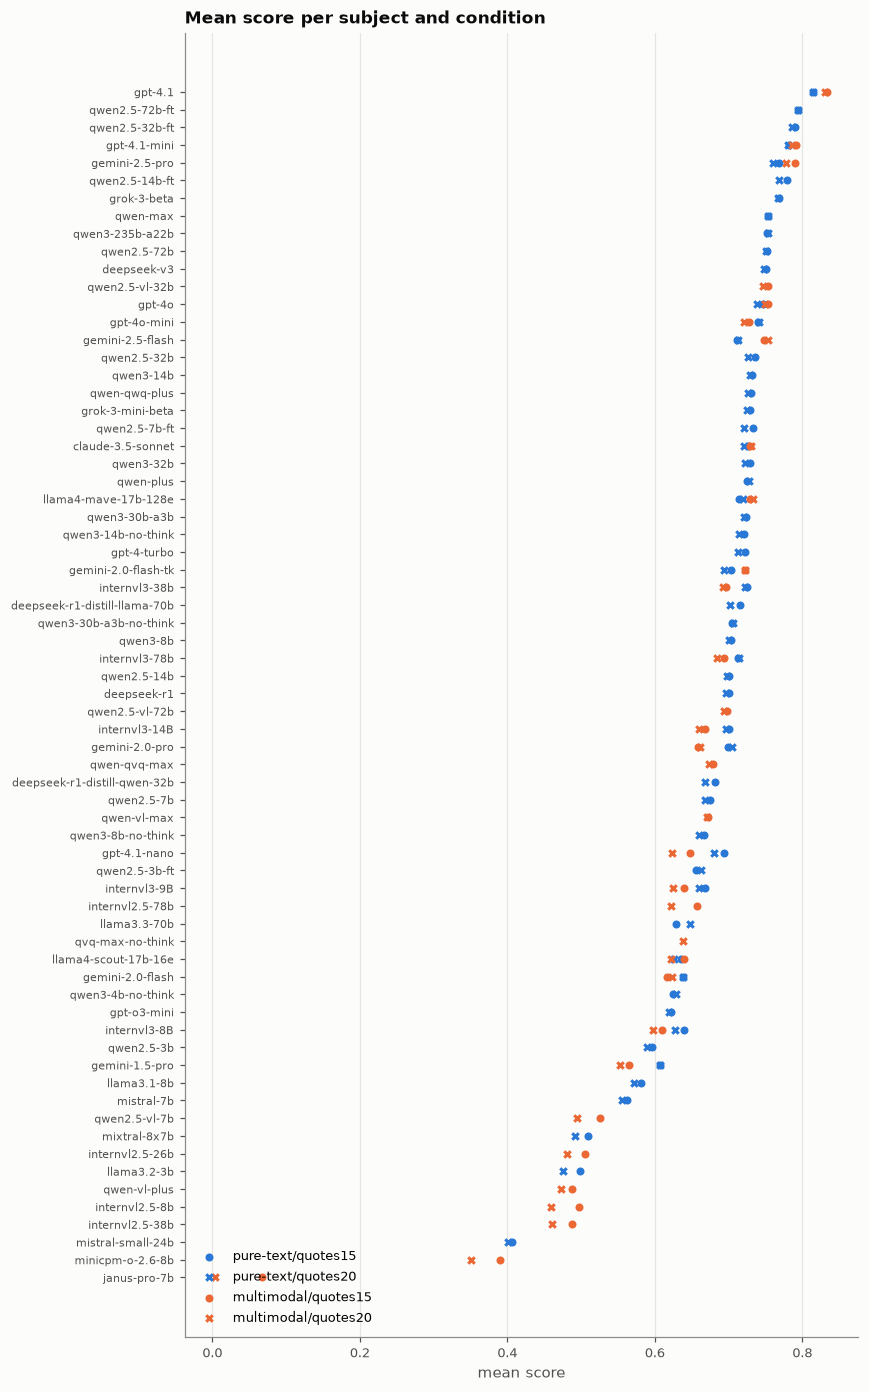

subject mean score: min 0.036 (janus-pro-7b), max 0.824 (gpt-4.1), IQR 0.628–0.729


In [20]:
order = sm["pure-text/quotes15"].sort_values(ascending=False)
fig, axes = panels(1, width=8, height=0.17 * len(sm) + 1.2)
ax = axes[0]
y = np.arange(len(sm))[::-1]
names = sm.mean(axis=1).sort_values(ascending=False).index
for cond, colour, marker in [("pure-text/quotes15", BLUE, "o"), ("pure-text/quotes20", BLUE, "x"),
                             ("multimodal/quotes15", ORANGE, "o"), ("multimodal/quotes20", ORANGE, "x")]:
    ax.scatter(sm.loc[names, cond], y, color=colour, marker=marker, s=18, label=cond)
ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=7.5)
ax.set_title("Mean score per subject and condition")
ax.set_xlabel("mean score")
ax.legend(loc="lower left")
ax.grid(axis="y", visible=False)
show(fig)
spread = sm.mean(axis=1)
print(f"subject mean score: min {spread.min():.3f} ({spread.idxmin()}), max {spread.max():.3f} ({spread.idxmax()}), "
      f"IQR {spread.quantile(0.25):.3f}–{spread.quantile(0.75):.3f}")

In [21]:
# Fine-tuned vs base Qwen2.5 of the same size (pure-text): the -ft models were trained by the MMDocRAG authors.
ft = sm.loc[[n for n in sm.index if n.endswith("-ft")], ["pure-text/quotes15", "pure-text/quotes20"]]
base = sm.loc[[n.removesuffix("-ft") for n in ft.index], ["pure-text/quotes15", "pure-text/quotes20"]]
display(pd.DataFrame({"base": base["pure-text/quotes15"].values, "fine-tuned": ft["pure-text/quotes15"].values},
                     index=base.index).assign(gain=lambda d: d["fine-tuned"] - d.base).round(3))

# Thinking vs no-thinking variants of the same model, on the conditions both were run on.
THINK_PAIR = {"qvq-max-no-think": "qwen-qvq-max"}
rows = {}
for b in [n for n in sm.index if n.endswith("-no-think")]:
    a = THINK_PAIR.get(b, b.removesuffix("-no-think"))
    if a in sm.index:
        shared = sm.loc[[a, b]].dropna(axis=1).columns
        rows[a] = {"conditions": ", ".join(shared), "thinking": sm.loc[a, shared].mean(), "no-think": sm.loc[b, shared].mean()}
display(pd.DataFrame(rows).T.assign(gain=lambda d: d.thinking.astype(float) - d["no-think"].astype(float)).round(3))

,base,fine-tuned,gain
display_name,,,
qwen2.5-14b,0.701,0.780,0.079
qwen2.5-32b,0.735,0.790,0.055
qwen2.5-3b,0.596,0.656,0.060
qwen2.5-72b,0.752,0.794,0.041
qwen2.5-7b,0.675,0.733,0.058


,conditions,thinking,no-think,gain
qwen-qvq-max,multimodal/quotes20,0.673817,0.637918,0.036
qwen3-14b,"pure-text/quotes15, pure-text/quotes20",0.73045,0.717799,0.013
qwen3-30b-a3b,"pure-text/quotes15, pure-text/quotes20",0.722251,0.705315,0.017
qwen3-8b,"pure-text/quotes15, pure-text/quotes20",0.702197,0.663063,0.039


### 5.5 How much is the subject, how much the item?

In [22]:
def decompose(d, iters=10):
    d = d.dropna(subset=["response"])
    y, mu = d.response.values, d.response.mean()
    s_eff = pd.Series(0.0, index=d.subject_id.unique())
    i_eff = pd.Series(0.0, index=d.item_id.unique())
    for _ in range(iters):
        i_eff = (d.response - mu - s_eff.reindex(d.subject_id).values).groupby(d.item_id.values).mean()
        s_eff = (d.response - mu - i_eff.reindex(d.item_id).values).groupby(d.subject_id.values).mean()
    fit_s, fit_i = s_eff.reindex(d.subject_id).values, i_eff.reindex(d.item_id).values
    resid = y - mu - fit_s - fit_i
    tot = y.var()
    return {"subjects": d.subject_id.nunique(), "rows": len(d), "total var": tot,
            "subject share": fit_s.var() / tot, "item share": fit_i.var() / tot, "residual share": resid.var() / tot}


display(pd.DataFrame({c: decompose(g) for c, g in resp.groupby("test_condition")}).T.round(3))

,subjects,rows,total var,subject share,item share,residual share
multimodal/quotes15,31.0,61944.0,0.052,0.412,0.146,0.442
multimodal/quotes20,32.0,63940.0,0.056,0.433,0.148,0.418
pure-text/quotes15,55.0,108415.0,0.036,0.164,0.291,0.546
pure-text/quotes20,55.0,108267.0,0.037,0.167,0.296,0.538


In [23]:
# Item difficulty: is it the same across conditions, and across halves of the subjects?
im = resp.pivot_table(index="item_id", columns="test_condition", values="response", aggfunc="mean")
print("Spearman of item means across conditions:")
display(im.corr(method="spearman").round(3))

rng = np.random.default_rng(0)
pt = resp[resp.test_condition == "pure-text/quotes15"]
subs = pt.subject_id.unique()
rs = []
for _ in range(20):
    h = set(rng.choice(subs, len(subs) // 2, replace=False))
    a = pt[pt.subject_id.isin(h)].groupby("item_id").response.mean()
    b = pt[~pt.subject_id.isin(h)].groupby("item_id").response.mean()
    rs.append(a.corr(b))
r = np.mean(rs)
print(f"split-half (random halves of subjects, pure-text/quotes15) Pearson r of item means: {r:.3f} · "
      f"Spearman–Brown: {2 * r / (1 + r):.3f}")

Spearman of item means across conditions:


test_condition,multimodal/quotes15,multimodal/quotes20,pure-text/quotes15,pure-text/quotes20
test_condition,,,,
multimodal/quotes15,1.000,0.878,0.728,0.704
multimodal/quotes20,0.878,1.000,0.711,0.743
pure-text/quotes15,0.728,0.711,1.000,0.936
pure-text/quotes20,0.704,0.743,0.936,1.000


split-half (random halves of subjects, pure-text/quotes15) Pearson r of item means: 0.939 · Spearman–Brown: 0.969


## 6. The judge: five grades behind each score


In [24]:
DIMS = ["Fluency", "Citation Quality", "Text-Image Coherence", "Reasoning Logic", "Factuality"]
FNAME = re.compile(r"(.+?)_(pure-text|multimodal)_(?:response_)?quotes(\d+)")
canon = lambda k: re.sub(r"[^a-z]", "", str(k).lower())  # judge spells keys inconsistently: 'fluency', 'CitationQuality', "' Factuality'"
CANON = {canon(k): k for k in DIMS}
rows = []
for f in sorted((RAW / "eval").glob("*.jsonl")):
    m = FNAME.match(f.name)
    for line in f.open():
        d = json.loads(line)
        g = {CANON[canon(k)]: v for k, v in (d["response"] or {}).items() if canon(k) in CANON}
        rows.append({"file_model": m.group(1), "mode": m.group(2), "quotes": int(m.group(3)), "q_id": d["q_id"],
                     "judge": d.get("model"), **{k: g.get(k) for k in DIMS}})
judge = pd.DataFrame(rows)
judge["display_name"] = judge.file_model.str.lower()
for k in DIMS:
    judge[k] = pd.to_numeric(judge[k], errors="coerce")
judge["complete"] = judge[DIMS].notna().all(axis=1)
print(f"{len(judge):,} judge records from {judge.file_model.nunique()} file names "
      f"({judge.display_name.nunique()} after lower-casing) · complete five grades: {judge.complete.mean():.4%}")
print("file names that differ only by case:", sorted(judge.file_model[judge.file_model != judge.display_name].unique()))

j = resp.assign(display_name=resp.display_name.str.lower()).merge(
    judge, on=["display_name", "mode", "quotes", "q_id"], how="left", validate="one_to_one")
print("responses matched to a judge record:", j.complete.notna().mean())
recomputed = j[DIMS].mean(axis=1, skipna=False) / 5
print("build score == mean of five grades ÷ 5:", np.isclose(j.response, recomputed).sum(), "of", j.response.notna().sum(),
      "· build score missing exactly when a grade is missing:", (j.response.isna() == ~j.complete.astype(bool)).all())

342,695 judge records from 73 file names (68 after lower-casing) · complete five grades: 99.9624%
file names that differ only by case: ['Internvl3-38B', 'Internvl3-78B', 'internvl3-14B', 'internvl3-8B', 'internvl3-9B']


responses matched to a judge record: 1.0
build score == mean of five grades ÷ 5: 342566 of 342566 · build score missing exactly when a grade is missing: True


judge,gpt-4o-2024-08-06,gpt-4o-2024-08-06_vlm
test_condition,,
multimodal/quotes15,23996,37970
multimodal/quotes20,27995,35968
pure-text/quotes15,49982,58476
pure-text/quotes20,51982,56326


one judge label per answer file: True · pure-text subjects whose answers are labelled '_vlm': 30 of 55


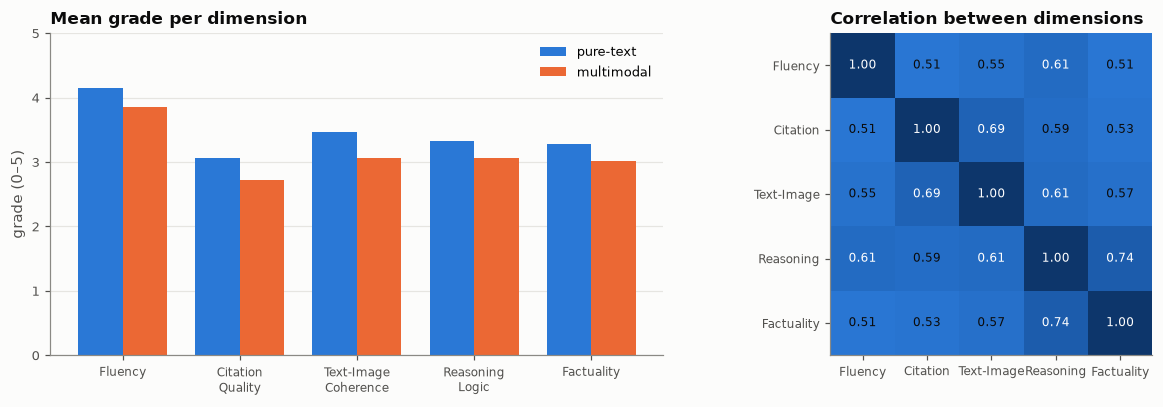

share of variance of the 5-grade sum explained by its first principal component: 0.675


In [25]:
display(pd.crosstab(j.test_condition, j.judge))
labels = j.groupby(["display_name", "mode", "quotes"]).judge.nunique()
pt_label = j[j["mode"] == "pure-text"].groupby("display_name").judge.first()
print(f"one judge label per answer file: {labels.eq(1).all()} · pure-text subjects whose answers are labelled "
      f"'_vlm': {pt_label.str.endswith('_vlm').sum()} of {len(pt_label)}")
fig, axes = panels(2, width=6, height=3.8)
dm = j.groupby("mode")[DIMS].mean().T
x = np.arange(len(DIMS))
for k, (mode, colour) in enumerate(MODE_COLOR.items()):
    axes[0].bar(x + (k - 0.5) * 0.38, dm[mode], width=0.38, color=colour, label=mode)
axes[0].set_xticks(x)
axes[0].set_xticklabels([d.replace(" ", "\n") for d in DIMS], fontsize=8)
axes[0].set_ylim(0, 5)
axes[0].set_title("Mean grade per dimension")
axes[0].set_ylabel("grade (0–5)")
axes[0].legend()
axes[0].grid(axis="x", visible=False)
cm = j[DIMS].corr()
im_ = axes[1].imshow(cm, cmap=SEQ, vmin=0, vmax=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([d.split()[0] for d in DIMS], fontsize=8)
axes[1].set_yticks(x)
axes[1].set_yticklabels([d.split()[0] for d in DIMS], fontsize=8)
for a in range(len(DIMS)):
    for b in range(len(DIMS)):
        axes[1].text(b, a, f"{cm.iloc[a, b]:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if cm.iloc[a, b] > 0.6 else INK)
axes[1].set_title("Correlation between dimensions")
axes[1].grid(False)
show(fig)
print("share of variance of the 5-grade sum explained by its first principal component:",
      round(np.linalg.eigvalsh(cm)[-1] / len(DIMS), 3))

In [26]:
bad = j[~j.complete.astype(bool)]
print(f"responses without five valid grades: {len(bad)} · by condition: {bad.test_condition.value_counts().to_dict()}")
print("most affected subjects:", bad.display_name.value_counts().head(5).to_dict())

responses without five valid grades: 129 · by condition: {'pure-text/quotes15': 43, 'pure-text/quotes20': 41, 'multimodal/quotes20': 23, 'multimodal/quotes15': 22}
most affected subjects: {'gpt-4.1': 9, 'gpt-4o-mini': 8, 'gpt-4.1-mini': 6, 'internvl2.5-8b': 6, 'internvl3-14b': 6}


## 7. What makes an item hard

,spearman vs pure-text/15,spearman vs multimodal/15
n_gold_img,-0.152,-0.197
q_chars,-0.046,-0.082
ev_table,-0.043,-0.007
ev_layout,-0.036,-0.045
n_gold,-0.007,-0.033
ev_figure,0.002,0.013
ctx_chars_15,0.008,-0.010
ctx_chars_20,0.009,-0.022
answer_chars,0.049,-0.059
ev_chart,0.064,0.006


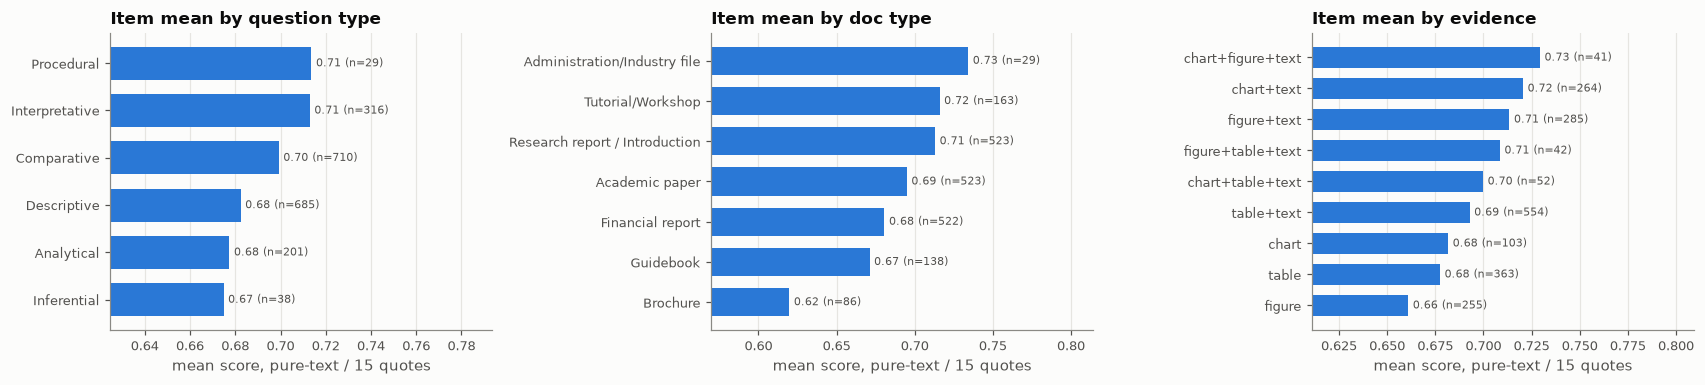

In [27]:
iv = iv.join(im)
iv["mm_gain_15"] = iv["multimodal/quotes15"] - iv["pure-text/quotes15"]  # on different subject sets; see below
target = "pure-text/quotes15"
cols = NUM + [f"ev_{m}" for m in ["text", "table", "chart", "figure", "layout"]]
corr = pd.DataFrame({
    "spearman vs pure-text/15": {c: spearman(iv[c].astype(float), iv[target]) for c in cols},
    "spearman vs multimodal/15": {c: spearman(iv[c].astype(float), iv["multimodal/quotes15"]) for c in cols},
}).sort_values("spearman vs pure-text/15")
display(corr.round(3))

fig, axes = panels(3, width=5.2, height=3.6)
for ax, col in zip(axes, ["question_type", "doc_type", "evidence"]):
    g = iv.groupby(col)[target].agg(["mean", "size"])
    g = g[g["size"] >= 20].sort_values("mean")
    ax.barh([short(i, 32) for i in g.index], g["mean"], color=BLUE, height=0.7)
    for yy, (v, n) in enumerate(zip(g["mean"], g["size"])):
        ax.annotate(f"{v:.2f} (n={n})", (v, yy), xytext=(3, 0), textcoords="offset points", va="center", fontsize=7.5, color=INK2)
    ax.set_xlim(g["mean"].min() - 0.05, g["mean"].max() + 0.08)
    ax.set_title(f"Item mean by {col.replace('_', ' ')}")
    ax.set_xlabel("mean score, pure-text / 15 quotes")
    ax.grid(axis="y", visible=False)
show(fig)

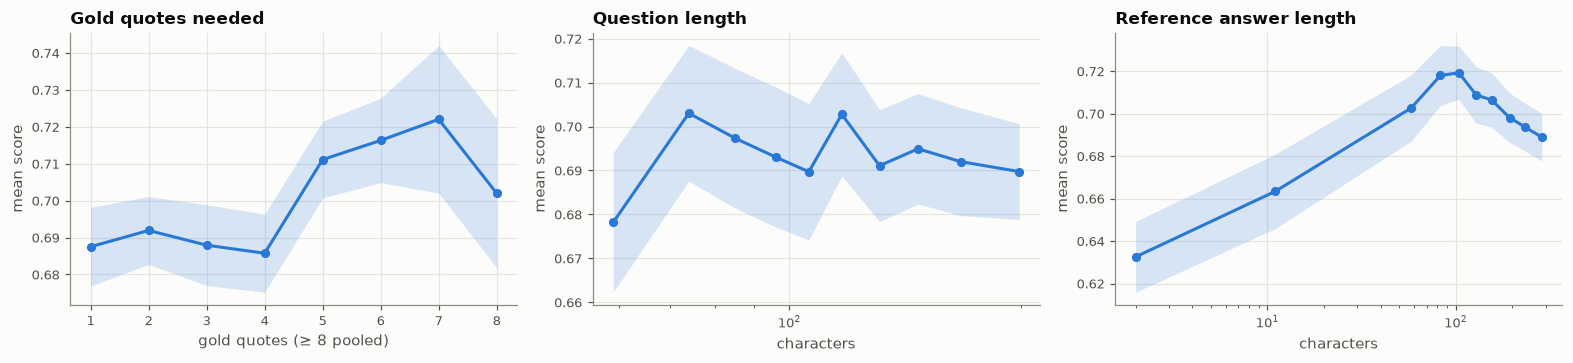

In [28]:
fig, axes = panels(3, width=4.8)
binned_mean(axes[0], iv.n_gold, iv[target], "Gold quotes needed", "gold quotes", clip=8)
binned_mean(axes[1], iv.q_chars, iv[target], "Question length", "characters", logx=True)
binned_mean(axes[2], iv.answer_chars, iv[target], "Reference answer length", "characters", logx=True)
show(fig)

In [29]:
# Where does seeing the images help? Paired within subject and item (subjects run in both modes, 15 quotes).
d = (wide["multimodal/quotes15"] - wide["pure-text/quotes15"]).dropna().rename("gain").reset_index()
d = d.merge(iv[["n_gold_img", "evidence"]], left_on="item_id", right_index=True)
print(f"mean paired gain of multimodal over pure-text: {d.gain.mean():+.4f} ({len(d):,} pairs)")
display(d.groupby("evidence").gain.agg(["mean", "size"]).query("size >= 500").sort_values("mean").round(4))
display(d.groupby(d.n_gold_img.clip(upper=4)).gain.agg(["mean", "size"]).rename_axis("image quotes in gold (≥ 4 pooled)").round(4))

mean paired gain of multimodal over pure-text: -0.0090 (37,892 pairs)


,mean,size
evidence,,
chart,-0.0478,1954
figure+table+text,-0.0265,797
chart+text,-0.0200,5006
chart+table+text,-0.0156,986
figure+text,-0.0126,5404
chart+figure+text,-0.0088,777
table+text,-0.0053,10489
figure,-0.0021,4835
table,0.0056,6866


,mean,size
image quotes in gold (≥ 4 pooled),,
0,0.0278,95
1,-0.0058,21066
2,-0.0131,11879
3,-0.0184,3750
4,0.0033,1102


## 8. Traces: the models' answers

`traces.parquet` holds the answer text each model produced. `raw/resp/*.jsonl` additionally has token counts.

In [30]:
tt = pq.read_table(DIR / "traces.parquet", columns=["response_id", "trace"])
tr = pd.DataFrame({"response_id": tt["response_id"].to_pandas(), "chars": pc.utf8_length(tt["trace"]).to_numpy()})
del tt
print(f"{len(tr):,} traces · response_id unique: {tr.response_id.is_unique} · orphans: "
      f"{(~tr.response_id.isin(resp.response_id)).sum()} · empty: {(tr.chars == 0).sum()}")
no_trace = ~resp.response_id.isin(tr.response_id)
print(f"responses without a trace: {no_trace.sum():,} ({no_trace.mean():.1%}) · their mean score "
      f"{resp.response[no_trace].mean():.3f} vs {resp.response[~no_trace].mean():.3f} with a trace")
display(resp[no_trace].groupby(["display_name", "test_condition"]).size().unstack(fill_value=0)
        .loc[lambda d: d.sum(axis=1) > 100])

328,286 traces · response_id unique: True · orphans: 0 · empty: 0


responses without a trace: 14,409 (4.2%) · their mean score 0.697 vs 0.667 with a trace


test_condition,multimodal/quotes15,multimodal/quotes20,pure-text/quotes15,pure-text/quotes20
display_name,,,,
internvl3-38b,0,2000,1999,1999
internvl3-78b,2000,2000,1999,1999
janus-pro-7b,154,5,0,0


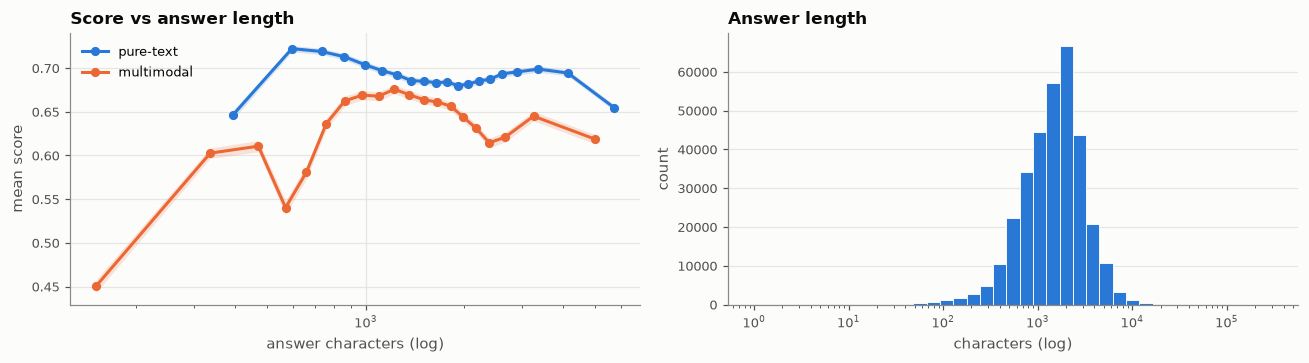

Spearman(answer length, score): +0.014 overall; within subject (mean of per-subject correlations): -0.091


In [31]:
rt = resp.merge(tr, on="response_id")
fig, axes = panels(2, width=6)
for mode, colour in MODE_COLOR.items():
    s = rt[rt["mode"] == mode]
    binned_mean(axes[0], s.chars, s.response, "Score vs answer length", "answer characters (log)", logx=True,
                color=colour, label=mode, q=20)
axes[0].legend()
hist(axes[1], rt.chars, "Answer length", "characters (log)", logx=True)
show(fig)
print(f"Spearman(answer length, score): {spearman(rt.chars, rt.response):+.3f} overall; within subject (mean of "
      f"per-subject correlations): {rt.groupby('subject_id')[['chars', 'response']].corr(method='spearman').xs('chars', level=1).response.mean():+.3f}")

In [32]:
# Raw response files: which runs exist, and their token counts.
FNAME_R = re.compile(r"(.+?)_(pure-text_ocr|pure-text|multimodal)_(?:response_)?quotes(\d+)")
rows = []
for f in sorted((RAW / "resp").glob("*.jsonl")):
    m = FNAME_R.match(f.name)
    for line in f.open():
        d = json.loads(line)
        rows.append({"display_name": m.group(1).lower(), "mode": m.group(2), "quotes": int(m.group(3)), "q_id": d["q_id"],
                     "in_tok": d.get("in_tok"), "out_tok": d.get("out_tok"),
                     "text_chars": len(d.get("response") or "")})
raw_resp = pd.DataFrame(rows)
print(f"{len(raw_resp):,} raw responses · by mode: {raw_resp['mode'].value_counts().to_dict()}")
ocr = raw_resp[raw_resp["mode"] == "pure-text_ocr"]
print(f"pure-text_ocr runs (images given as OCR text): {ocr.display_name.nunique()} subjects, {len(ocr):,} answers — "
      f"no judge records, so not in the build")

k = resp.assign(display_name=resp.display_name.str.lower()).merge(raw_resp, on=["display_name", "mode", "quotes", "q_id"],
                                                                 how="left", validate="one_to_one")
print("build responses with a raw answer file:", k.in_tok.notna().mean().round(4))
print("prompt tokens (in_tok) by condition, median:", k.groupby("test_condition").in_tok.median().to_dict())

382,000 raw responses · by mode: {'pure-text': 224000, 'multimodal': 126000, 'pure-text_ocr': 32000}
pure-text_ocr runs (images given as OCR text): 8 subjects, 32,000 answers — no judge records, so not in the build


build responses with a raw answer file: 0.9883
prompt tokens (in_tok) by condition, median: {'multimodal/quotes15': 5539.5, 'multimodal/quotes20': 7835.0, 'pure-text/quotes15': 2514.0, 'pure-text/quotes20': 3422.0}


In [33]:
rng = np.random.default_rng(0)
sample = rt.sample(2, random_state=1)
traces_s = pq.read_table(DIR / "traces.parquet", filters=[("response_id", "in", sample.response_id.tolist())]).to_pandas()
for _, row in sample.merge(traces_s[["response_id", "trace"]], on="response_id").iterrows():
    print(f"--- {row.display_name} · {row.test_condition} · q_id {row.q_id} · score {row.response} ---")
    print(textwrap.shorten(row.trace, 600, placeholder=" …"), "\n")

--- gpt-4.1-nano · multimodal/quotes15 · q_id 792 · score 0.8 ---
The total deposits increased from December 31, 2019, to December 31, 2020. Specifically, as shown in the first image, deposits rose from approximately $190.36 billion in 2019 to about $310.78 billion in 2020, reflecting a significant growth. ![Savings and demand deposits at December 31, 2020, and 2019](image1) *Deposits increased due to higher brokerage sweep deposits and savings, partly driven by the acquisition of E*TRADE.* The key factors contributing to this increase include: - Growth in brokerage sweep deposits, which increased substantially from $121,077 million in 2019 to $232,071 … 

--- internvl3-38b · multimodal/quotes15 · q_id 321 · score 0.72 ---
To evaluate how 'Our Approach' compares to other methods on the LANI and CHAI datasets, we can analyze the provided text and image quotes. **LANI Dataset:** - According to text [3], 'Our Approach' outperforms CHAPLOT 18 by improving task completion (TC) accuracy by 5

- 14,409 scored responses (4.2%) have no answer text: `internvl3-38b` and `internvl3-78b` in three or four
  conditions, and 159 from `janus-pro-7b`. Answer text is a post-hoc feature anyway.
- Answer length barely relates to the score (ρ +0.01 overall, −0.09 within subject), so there is no strong
  length bias in the judge.
- `raw/resp` also has a third mode, `pure-text_ocr` (images given as OCR text): 8 subjects × 4,000 answers that
  were never judged, so they are not in the build.
- Prompt size is known before inference. The median `in_tok` is 2.5k tokens for pure-text with 15 quotes and
  3.4k with 20; multimodal prompts are larger (5.5k and 7.8k) because images count as tokens.

## 9. Implications for the assessor dataset

These are inputs for the formatting step, not decisions yet.

- **Item = question × condition.** The same question under the four conditions has a different input and a
  different difficulty (ρ 0.70–0.94). Option: `item_id = mmdocrag:<q_id>@<mode>/quotes<N>`, giving 8,000 items.
- **The question must include the context.** Build `question` from the raw question files: the question plus
  the 15 or 20 quotes. For pure-text, images become their descriptions, exactly as the model saw them. For
  multimodal, the images must be downloaded from upstream.
- **Target:** the build score as is (a fraction, one judge call per answer), `n_runs = 1`. Drop the 129
  missing scores. `score_type = fraction`.
- **Ground truth:** `answer_short` (in the build) or `answer_interleaved` (raw, the long cited answer).
- **Item columns:** `eval_type = judge`; `modality` = text for pure-text, text + image for multimodal;
  `multi_turn = false`; `agentic = false`; harness empty.
- **Subjects:**
  - The `-ft` models are tuned to this benchmark: flag or exclude them.
  - Thinking and no-think variants share `normalized_name`, so curated model attributes must be keyed by variant.
  - Check `gpt-4-turbo`'s normalisation and release date.
- **Judge caveat:** the judge label does not follow the mode for 30 pure-text subjects (§6).